# MIDI Index Metdata Exploration

This notebooks serves to explore the dataset and the attatched metadata to give more contaxt and understanding around the problem.

In [13]:
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt

import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.config.paths import MSD_METADATA_DIR, PROCESSED_DATA_DIR, LMD_MATCHED_DIR

In [4]:
df = pd.read_csv(f"{PROCESSED_DATA_DIR}/metadata_index.csv")

In [5]:
df.head()

,track_id,artist_name,artist_id,title,song_id,release,genre,midi_path
0,TRAAAGR128F425B14B,Cyndi Lauper,ARGE7G11187FB37E05,Into The Nightlife,SONRWUU12AF72A4283,Bring Ya To The Brink,NaN,C:\Users\danie\Documents\GitHub\music-represen...
1,TRAAAZF12903CCCF6B,Matthew Wilder,ARJJ8611187FB5321F,Break My Stride,SOUCVHW12AB018E830,I Don't Speak The Language,NaN,C:\Users\danie\Documents\GitHub\music-represen...
2,TRAABVM128F92CA9DC,Tesla,ARYKCQI1187FB3B18F,Caught In A Dream,SOXLBJT12A8C140925,Gold,NaN,C:\Users\danie\Documents\GitHub\music-represen...
3,TRAABXH128F42955D6,Brian Wilson,ARD9UVF1187B9B17FE,Keep An Eye On Summer (Album Version),SOHXFBA12A8C13D637,Imagination,NaN,C:\Users\danie\Documents\GitHub\music-represen...
4,TRAACQE12903CC706C,Old Man River,ARDDIBO1187B9B0822,Summer,SOGUCAN12AB017BF99,Good Morning,NaN,C:\Users\danie\Documents\GitHub\music-represen...


In [6]:
df.shape

(31034, 8)

I wanted to double check that files match up correctly with no metdata missing or duplicated.

In [7]:
df['track_id'].nunique() - df.shape[0]

0

In [14]:
missing_files = []
found_files = []


for file in Path(f"{LMD_MATCHED_DIR}").glob("*.mid"):
    if file not in df['track_id'].values:
        missing_files.append(file)
    else:
        found_files.append(file)

In [15]:
missing_files
found_files

[]

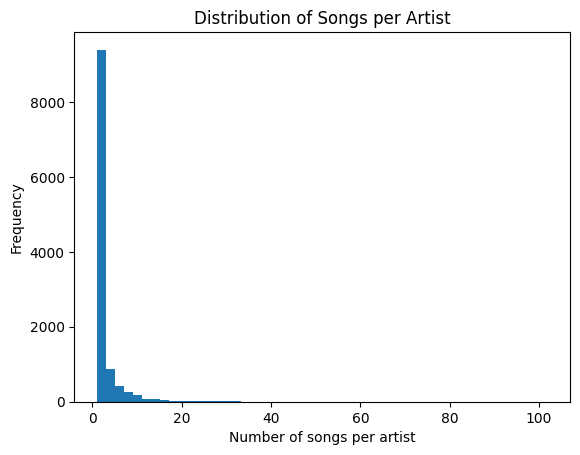

In [16]:
artist_counts = df["artist_name"].value_counts()

plt.figure()
plt.hist(artist_counts.values, bins=50)
plt.xlabel("Number of songs per artist")
plt.ylabel("Frequency")
plt.title("Distribution of Songs per Artist")
plt.show()

There is skew and distortion on the plot here from outliers. As such a filtered plot is produced

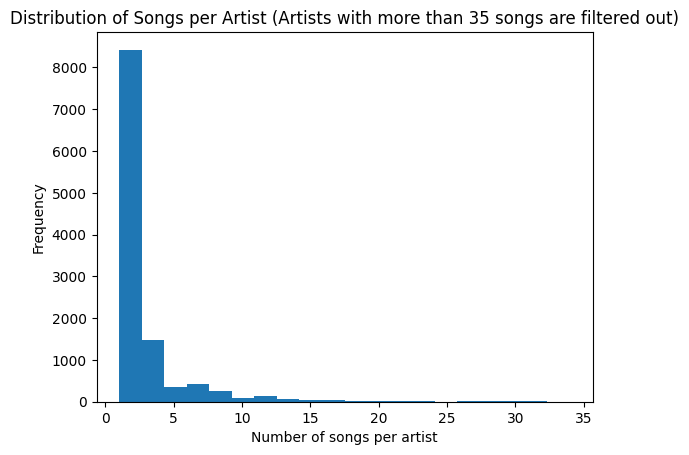

In [17]:
artist_counts_filtered = artist_counts[artist_counts < 35]

plt.figure()
plt.hist(artist_counts_filtered.values, bins=20)
plt.xlabel("Number of songs per artist")
plt.ylabel("Frequency")
plt.title("Distribution of Songs per Artist (Artists with more than 35 songs are filtered out)")
plt.show()

Simmilralry I wanted to get some idea of how many MIDI files there are per track, with each track ID folder often containing more than one MIDI file.